# August 2026 desktop — canonical plots for the s01 candidate

**This is a CANDIDATE, not a delivered forecast.** The delivered/canonical August view is
`data-official/2026-08/august_canonical_v2026-07-28.ipynb`. This notebook renders the same
chart format for the best configuration the summer-trough search has produced, so the two are
visually comparable.

## The candidate

July's `s01` config (the 28-point Latin-hypercube winner from
`research/param-scans/aug22-retune/`, never adopted there) rebuilt at the August 2026-07-28
anchor:

```
seasonality_regime = multiplicative
changepoint_prior_scale = 0.1849      (canonical: 0.08983)
changepoint_range       = 0.734       (canonical: 0.65)
recent_weeks            = 17          (canonical: 13)
n_changepoints          = 35          (canonical: 25)
seasonality_prior_scale = 0.00825     (unchanged)
holiday_*               = package defaults, IDENTICAL to canonical
```

Holiday parameters are at defaults and are **permanently excluded** from this search: they
produce strictly local effects, so using them to move a whole-season quantity is compensating
for an overall trend with a small regional fix. The `[verify]` cell asserts this rather than
trusting it.

## Why it matters

| | canonical Aug | s01 candidate |
|---|--:|--:|
| Aug-25 trough min | 43,833,674 | **45,193,561** |
| Dec-15 28d-MA | 48,672,970 | **48,678,612** (+5,642) |
| seam slope kink | −72,593/day | **−20,604/day** |

It satisfies all three objectives at once: trough inside the 45–46M target band, Dec-15 inside
±50,000, and a substantially better derivative match across the seam.

## Conventions — matched to the canonical notebook

- Forecast curves use the variance-matched `display_ma` seam splice; actuals use plain
  `daily_to_28ma`.
- The Win10 headwind (`h`) is applied at the **display layer** from each curve's own seam, via
  the production `apply_net_adjustment_to_series`. August: −1,245,000 at the 2026-12-15 anchor,
  ramping from the seam. The July prior line reads July's **own** spec dir (−1,345,000, ramp
  from 2026-04-01) so it keeps reproducing its delivered value.
- The gold low/baseline/stretch markers are the **June-cycle aspirational benchmarks**, reused
  unchanged so the vertical scale stays comparable across cycles. They are *not* August targets.
- Overlays `l` (launch-on-login, a pre-200K ceiling held identical on both sides) and `o` (MozillaOnline) are baked into the
  parquet; `require_state=["l","o"]` enforces that.

⚠️ **Open caveat.** `changepoint_range` is the dominant lever here and its curvature is 2.4× its
own slope, so this config sits on a bending response surface rather than a flat optimum. It is
also a materially more flexible trend model than the shipped canonical (cps 2.1×, ncp 1.4×,
cpr 0.734 vs 0.65), which is worth scrutiny as a possible overfit in its own right.


In [1]:
# [setup]
import os
import subprocess
import sys
import json
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from google.cloud import bigquery

# Anchor at git root so relative paths work regardless of notebook location.
os.chdir(subprocess.run(["git", "rev-parse", "--show-toplevel"],
                        capture_output=True, text=True).stdout.strip())
sys.path.insert(0, "src")
# display_ma still lives under the June cycle dir (generic in forecast_start). Same
# dependency the canonical notebook carries; flagged there for the September roll-forward.

# The variance-matched seam MA now lives in the package: src/mozaic_daily/seam_ma.py. Cycles
# through 2026-07 import a frozen copy from data-official/2026-06/ so their delivered curves
# cannot move; new work imports from the package. seam_ma carries the A1 trend-estimator fix
# (deseasonalize before averaging) -- see research/ma-seam-turbulence/LOG.md, Fix A.
from mozaic_daily.seam_ma import display_ma  # noqa: E402
from mozaic_daily.adjustments import (  # noqa: E402
    load_forecast, load_adjustments_from_dir, apply_net_adjustment_to_series,
)

# --- The candidate: July's s01 config rebuilt at the August anchor ---
S01_FORECAST_PATH = (
    "research/param-scans/summer-trough-v2/s01_gradient/"
    "cps0.1849_thresh032_recent17_cpr0.734_ncp35_clip0.6_sps0.00825_regimemultiplicative/"
    "mozaic_daily_forecast.2026-07-28.ld-D.adj-lo.parquet"
)
# --- The canonical August build, for a same-cycle comparison ---
CANONICAL_FORECAST_PATH = (
    "data-official/2026-08/desktop_baseline_2026-07-28/"
    "cps0.08983_thresh032_recent13_cpr0.65_ncp25_clip0.6_sps0.00825/"
    "mozaic_daily_forecast.2026-07-28.ld-D.adj-lo.parquet"
)
# --- Prior (N-1) = July's DELIVERED forecast ---
PREV_FORECAST_DESKTOP_PATH = (
    "data-official/2026-07/desktop_locked/"
    "mozaic_daily_forecast.2026-07-06.ld-D.adj-lo.parquet"
)

ADJUSTMENTS_DIR = "data-official/2026-08/adjustments"
PREV_ADJUSTMENTS_DIR = "data-official/2026-07/adjustments"
PLOTS_DIR = "research/param-scans/summer-trough-v2/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# --- Dates ---
DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")
FORECAST_START = pd.Timestamp("2026-07-28")        # August seam
PREV_FORECAST_START = pd.Timestamp("2026-07-06")   # July's seam
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")
TROUGH_DATE = pd.Timestamp("2026-08-25")           # the scored trough minimum
BQ_START = "2025-12-04"                            # 28d lookback for the trailing MA

# --- Pinned reference values, asserted in [verify] ---
CANONICAL_TROUGH = 43_833_674
CANONICAL_DEC15 = 48_672_970
S01_TROUGH = 45_193_561
S01_DEC15 = 48_678_612
DEC_TOL = 50_000

print(f"cwd: {os.getcwd()}")
print(f"seam: {FORECAST_START.date()} | prior seam: {PREV_FORECAST_START.date()}")
print(f"plots -> {PLOTS_DIR}")


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


cwd: /Users/brendanwells/work/mozaic-daily
seam: 2026-07-28 | prior seam: 2026-07-06
plots -> research/param-scans/summer-trough-v2/plots


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# [helpers]
def load_all_level_dau(path, *, require_state):
    """World(ALL) daily desktop DAU from a validated forecast parquet, plus its meta."""
    df, meta = load_forecast(path, require_state=require_state)
    mask = (
        (df["country"] == "ALL")
        & (df["segment"] == '{"os": "ALL"}')
        & (df["data_source"] == "legacy_desktop")
        & (df["app_name"] == "desktop")
    )
    out = df.loc[mask, ["target_date", "dau", "data_type"]].copy()
    out["target_date"] = pd.to_datetime(out["target_date"])
    return out.sort_values("target_date").reset_index(drop=True), meta


def daily_to_28ma(dates, values):
    """Plain 28-day trailing MA. Used for ACTUALS (forecasts use display_ma)."""
    s = pd.Series(values.values, index=pd.to_datetime(dates.values))
    return s.sort_index().rolling(28).mean()


def adjusted_ma(raw, seam, adjustments_dir):
    """Forecast 28d-MA with the display-layer headwind applied from `seam` forward."""
    ma = display_ma(raw["target_date"], raw["dau"], seam)
    net = load_adjustments_from_dir(adjustments_dir, ma.index)
    return apply_net_adjustment_to_series(ma, net, "desktop", forecast_start=seam)


def millions_formatter(x, pos):
    # Two decimals so adjacent ticks stay distinguishable -- a whole-million format
    # would render 48.67M and 48.72M identically as "49M".
    return f"{x / 1e6:.2f}M"


def clip_display(s):
    return s[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)].dropna()


def clip_forecast_only(s, seam=None):
    seam = FORECAST_START if seam is None else seam
    return s[(s.index >= seam) & (s.index <= DISPLAY_END)].dropna()


def seam_slope(ma, seam, window=14):
    """OLS slope (DAU/day) over `window` days ending just before / starting at the seam."""
    def fit(a, b):
        seg = ma.loc[a:b].dropna()
        x = (seg.index - seg.index[0]).days.to_numpy(dtype=float)
        return float(np.polyfit(x, seg.to_numpy(dtype=float), 1)[0])
    before = fit(seam - pd.Timedelta(days=window), seam - pd.Timedelta(days=1))
    after = fit(seam, seam + pd.Timedelta(days=window - 1))
    return before, after, after - before


print("helpers defined")


helpers defined


In [3]:
# [load-and-verify]
# require_state pins the expected overlays: all three desktop curves must be adj-lo
# (launch-on-login + MozillaOnline). A run that silently missed its spec date would have
# emitted .raw. and this raises rather than quietly publishing a wrong number.
s01_raw, s01_meta = load_all_level_dau(S01_FORECAST_PATH, require_state=["l", "o"])
canon_raw, canon_meta = load_all_level_dau(CANONICAL_FORECAST_PATH, require_state=["l", "o"])
prev_raw, prev_meta = load_all_level_dau(PREV_FORECAST_DESKTOP_PATH, require_state=["l", "o"])

for label, df, seam in [("s01 candidate", s01_raw, FORECAST_START),
                        ("canonical Aug", canon_raw, FORECAST_START),
                        ("July prior", prev_raw, PREV_FORECAST_START)]:
    last_train = df.loc[df["data_type"] == "training", "target_date"].max()
    print(f"{label:15s} {len(df):5d} rows | seam {seam.date()} | last training {last_train.date()}")

# --- The candidate's config is exactly s01, and its holiday knobs are UNTOUCHED ---
EXPECTED_S01 = {
    "seasonality_regime": "multiplicative",
    "prophet_changepoint_prior_scale": 0.1849,
    "prophet_changepoint_range": 0.734,
    "prophet_recent_weeks": 17,
    "prophet_n_changepoints": 35,
    "prophet_seasonality_prior_scale": 0.00825,
}
# Holiday parameters are permanently excluded from this search (local effects must not be
# used to move a whole-season quantity). Assert it instead of trusting it: if a future
# rebuild moved one, the plots below would silently stop being holiday-clean.
HOLIDAY_DEFAULTS = {
    "holiday_threshold": -0.032, "holiday_max_radius": 5,
    "holiday_min_radius": 3, "holiday_effect_floor": -0.6,
}
cfg = s01_meta["model_config"]
drift = {k: (v, cfg.get(k)) for k, v in EXPECTED_S01.items() if cfg.get(k) != v}
assert not drift, f"candidate is not s01: {drift}"
hol_drift = {k: (v, cfg.get(k)) for k, v in HOLIDAY_DEFAULTS.items() if cfg.get(k) != v}
assert not hol_drift, f"HOLIDAY KNOBS ARE OFF-DEFAULT -- excluded by design: {hol_drift}"
print(f"\ncandidate config == s01 ({len(EXPECTED_S01)} params) "
      f"and holiday knobs are at defaults ({len(HOLIDAY_DEFAULTS)} checked)")

# The two August curves must differ ONLY in the trend/seasonality knobs.
ccfg = canon_meta["model_config"]
differing = {k for k in cfg if cfg[k] != ccfg.get(k)}
print(f"candidate vs canonical differs in: {sorted(differing)}")
assert not (differing & set(HOLIDAY_DEFAULTS)), \
    "candidate and canonical differ in a holiday knob -- comparison would be confounded"


s01 candidate    2922 rows | seam 2026-07-28 | last training 2026-07-27
canonical Aug    2922 rows | seam 2026-07-28 | last training 2026-07-27
July prior       2922 rows | seam 2026-07-06 | last training 2026-07-05

candidate config == s01 (6 params) and holiday knobs are at defaults (4 checked)
candidate vs canonical differs in: ['prophet_changepoint_prior_scale', 'prophet_changepoint_range', 'prophet_n_changepoints', 'prophet_recent_weeks', 'seasonality_corr_threshold', 'seasonality_regime']


In [4]:
# [bq-actuals]
# Legacy telemetry (never Glean). Cutoff = CURRENT_DATE("America/Los_Angeles") - 2: the
# most-recent landed day can be partial, and one short day poisons the trailing MA28
# endpoint. The LA-time clamp matters -- plain CURRENT_DATE() is UTC, so after ~5pm PDT it
# rolls to tomorrow and -2 lands ON the still-partial day. All countries, Iran included.
client = bigquery.Client(project="moz-fx-data-bq-data-science")

DESKTOP_ACTUALS_SQL = f"""
    SELECT submission_date AS date, SUM(dau) AS dau
    FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
    WHERE app_name = "Firefox Desktop"
      AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
    GROUP BY submission_date ORDER BY 1
"""

t0 = time.time()
sys.stdout.write("querying desktop actuals...")
sys.stdout.flush()
desktop_actuals = client.query(DESKTOP_ACTUALS_SQL).to_dataframe()
desktop_actuals["date"] = pd.to_datetime(desktop_actuals["date"])
sys.stdout.write(f" {len(desktop_actuals)} rows through "
                 f"{desktop_actuals['date'].max().date()} ({time.time() - t0:.1f}s)\n")
sys.stdout.flush()


querying desktop actuals...

 236 rows through 2026-07-27 (7.9s)


In [5]:
# [compute-series]
# Forecast curves: variance-matched display_ma + the display-layer Win10 headwind applied from
# each curve's OWN seam. The July prior reads July's own spec dir (-1,345,000, ramp from
# 2026-04-01); August reads -1,245,000 ramping from the seam. Keeping the dirs separate is what
# lets July keep reproducing its delivered value while August's spec is edited.
s01_ma = adjusted_ma(s01_raw, FORECAST_START, ADJUSTMENTS_DIR)
canon_ma = adjusted_ma(canon_raw, FORECAST_START, ADJUSTMENTS_DIR)
prev_ma = adjusted_ma(prev_raw, PREV_FORECAST_START, PREV_ADJUSTMENTS_DIR)

# Actuals use the PLAIN 28d MA -- no seam splice, there is no seam in history.
actual_ma = daily_to_28ma(desktop_actuals["date"], desktop_actuals["dau"])

# Trough minimum over the summer window, on each curve.
summer = slice(FORECAST_START, pd.Timestamp("2026-10-15"))
metrics = {}
for name, ma in [("canonical", canon_ma), ("s01", s01_ma)]:
    win = ma.loc[summer].dropna()
    before, after, kink = seam_slope(ma, FORECAST_START)
    metrics[name] = {
        "trough": win.min(), "trough_date": win.idxmin(),
        "aug15": ma.loc[pd.Timestamp("2026-08-15")],
        "aug25": ma.loc[TROUGH_DATE],
        "dec15": ma.loc[MEASUREMENT_DATE],
        "seam_before": before, "seam_after": after, "seam_kink": kink,
    }

print(f"{'':12s} {'trough min':>14s} {'on':>12s} {'Aug-15':>14s} {'Dec-15':>14s} {'seam kink':>11s}")
for name, m in metrics.items():
    print(f"{name:12s} {m['trough']:>14,.0f} {str(m['trough_date'].date()):>12s} "
          f"{m['aug15']:>14,.0f} {m['dec15']:>14,.0f} {m['seam_kink']:>+11,.0f}")

d = {k: metrics["s01"][k] - metrics["canonical"][k]
     for k in ("trough", "aug15", "dec15", "seam_kink")}
print(f"\ns01 - canonical: trough {d['trough']:+,.0f} | Aug-15 {d['aug15']:+,.0f} | "
      f"Dec-15 {d['dec15']:+,.0f} | seam kink {d['seam_kink']:+,.0f}")
print(f"actuals through {actual_ma.dropna().index.max().date()}")


                 trough min           on         Aug-15         Dec-15   seam kink
canonical        43,833,674   2026-08-25     44,586,315     48,672,970     -74,237
s01              45,193,561   2026-08-25     45,614,119     48,678,612     -19,702

s01 - canonical: trough +1,359,887 | Aug-15 +1,027,804 | Dec-15 +5,642 | seam kink +54,535
actuals through 2026-07-27


In [6]:
# [verify]
# Lock the headline numbers against the values reported from scripts/score_near_horizon.py.
# This is the cross-check that the notebook's plotting path and the scorer agree -- they are
# independent implementations of the same convention, so a mismatch means one is wrong.
checks = [
    ("canonical trough", metrics["canonical"]["trough"], CANONICAL_TROUGH),
    ("canonical Dec-15", metrics["canonical"]["dec15"], CANONICAL_DEC15),
    ("s01 trough", metrics["s01"]["trough"], S01_TROUGH),
    ("s01 Dec-15", metrics["s01"]["dec15"], S01_DEC15),
]
for label, got, want in checks:
    assert abs(got - want) < 1, f"{label}: notebook {got:,.0f} != scorer {want:,.0f}"
    print(f"  ok  {label:20s} {got:,.0f}")

# The criteria, restated as assertions so a future rebuild cannot quietly stop meeting them.
dec_drift = metrics["s01"]["dec15"] - CANONICAL_DEC15
assert abs(dec_drift) <= DEC_TOL, \
    f"s01 Dec-15 drift {dec_drift:+,.0f} exceeds the +-{DEC_TOL:,} budget"
assert 45_000_000 <= metrics["s01"]["trough"] <= 46_000_000, \
    f"s01 trough {metrics['s01']['trough']:,.0f} outside the 45-46M target band"
assert abs(metrics["s01"]["seam_kink"]) < abs(metrics["canonical"]["seam_kink"]), \
    "s01 seam kink is not an improvement on canonical"

print(f"\nAll three criteria met:")
print(f"  trough  {metrics['s01']['trough']:,.0f}  (target band 45-46M)")
print(f"  Dec-15  {metrics['s01']['dec15']:,.0f}  ({dec_drift:+,.0f}, budget +-{DEC_TOL:,}; "
      f"{100*abs(dec_drift)/DEC_TOL:.0f}% used)")
print(f"  kink    {metrics['s01']['seam_kink']:+,.0f}/day  "
      f"(canonical {metrics['canonical']['seam_kink']:+,.0f})")
print(f"\nDec-15 room remaining: {metrics['s01']['dec15'] - (CANONICAL_DEC15 - DEC_TOL):,.0f} down, "
      f"{(CANONICAL_DEC15 + DEC_TOL) - metrics['s01']['dec15']:,.0f} up")


  ok  canonical trough     43,833,674
  ok  canonical Dec-15     48,672,970
  ok  s01 trough           45,193,561
  ok  s01 Dec-15           48,678,612

All three criteria met:
  trough  45,193,561  (target band 45-46M)
  Dec-15  48,678,612  (+5,642, budget +-50,000; 11% used)
  kink    -19,702/day  (canonical -74,237)

Dec-15 room remaining: 55,642 down, 44,358 up


saved: research/param-scans/summer-trough-v2/plots/s01_desktop_vs_july.png


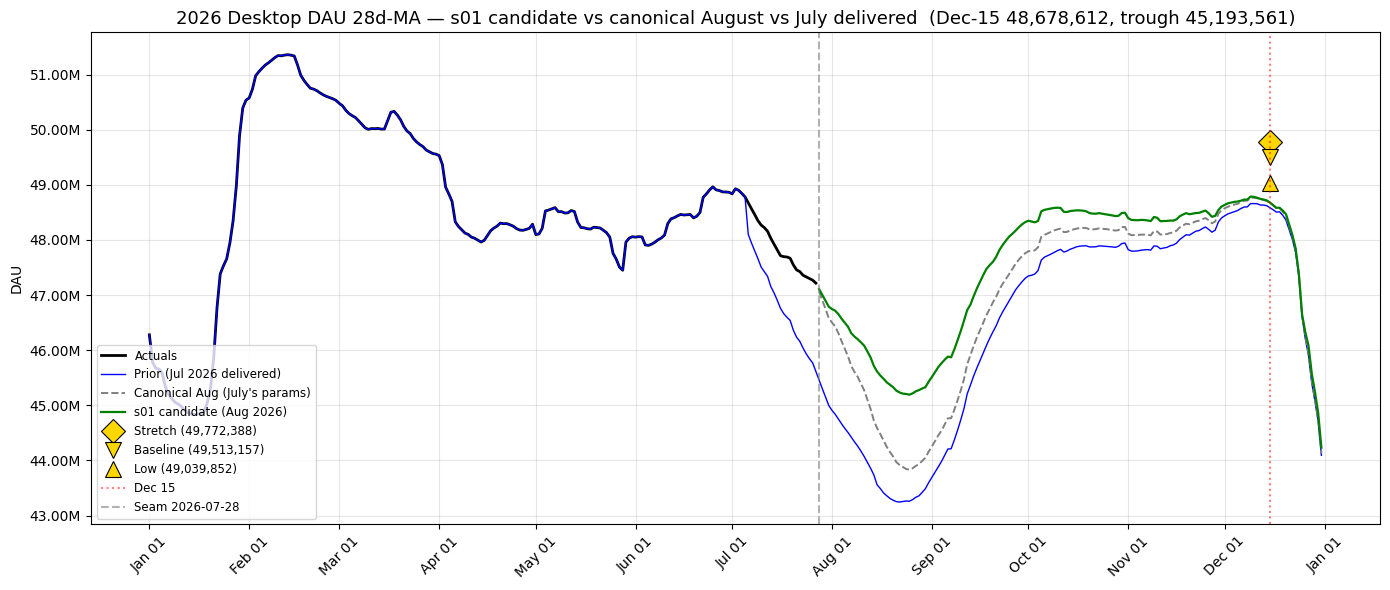

In [7]:
# [plot-vs-july]
# Gold markers are the JUNE-cycle aspirational benchmarks, reused unchanged in July and here so
# the vertical scale stays comparable across the three cycles' charts. They are NOT August
# targets -- no August target has been set.
STAKEHOLDER_DESKTOP_LOW = 49_039_852
STAKEHOLDER_DESKTOP_BASELINE = 49_513_157
STAKEHOLDER_DESKTOP_STRETCH = 49_772_388


def render_desktop_plot(*, show_prior, show_canonical, title, savename):
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(clip_display(actual_ma), label="Actuals", color="black", linewidth=2)
    if show_prior:
        ax.plot(clip_display(prev_ma), label="Prior (Jul 2026 delivered)",
                color="blue", linewidth=1)
    if show_canonical:
        ax.plot(clip_forecast_only(canon_ma), label="Canonical Aug (July's params)",
                color="grey", linewidth=1.4, linestyle="--")
    ax.plot(clip_forecast_only(s01_ma), label="s01 candidate (Aug 2026)",
            color="green", linewidth=1.6)

    for value, marker, label in [
        (STAKEHOLDER_DESKTOP_STRETCH, "D", "Stretch"),
        (STAKEHOLDER_DESKTOP_BASELINE, "v", "Baseline"),
        (STAKEHOLDER_DESKTOP_LOW, "^", "Low"),
    ]:
        ax.plot(MEASUREMENT_DATE, value, marker=marker, color="gold", markersize=12,
                markeredgecolor="black", markeredgewidth=0.8, linestyle="None",
                label=f"{label} ({value:,})")
    ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
    ax.axvline(FORECAST_START, color="grey", linestyle="--", alpha=0.6,
               label=f"Seam {FORECAST_START.date()}")

    ax.set_title(title, fontsize=13)
    ax.set_ylabel("DAU")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.legend(loc="lower left", fontsize=8.5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    out = f"{PLOTS_DIR}/{savename}"
    fig.savefig(out, dpi=130)
    print(f"saved: {out}")
    plt.show()


render_desktop_plot(
    show_prior=True, show_canonical=True,
    title=("2026 Desktop DAU 28d-MA — s01 candidate vs canonical August vs July delivered  "
           f"(Dec-15 {metrics['s01']['dec15']:,.0f}, trough {metrics['s01']['trough']:,.0f})"),
    savename="s01_desktop_vs_july.png")


saved: research/param-scans/summer-trough-v2/plots/s01_desktop_only.png


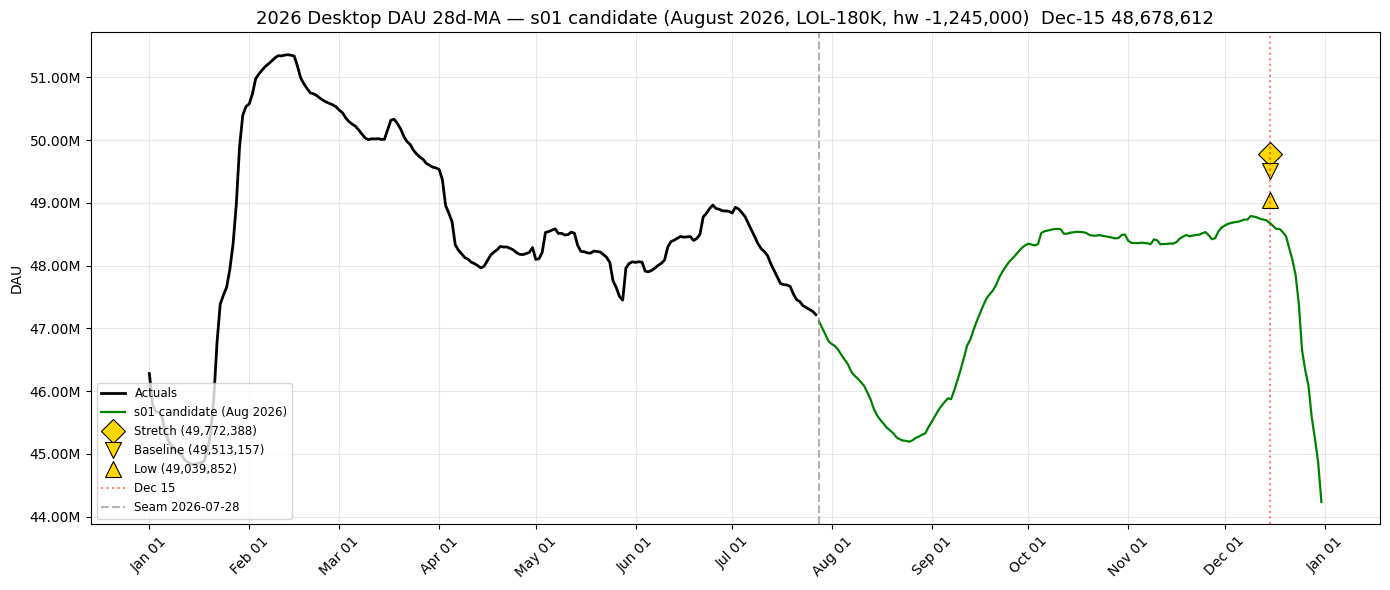

In [8]:
# [plot-candidate-only]
render_desktop_plot(
    show_prior=False, show_canonical=False,
    title=("2026 Desktop DAU 28d-MA — s01 candidate (August 2026, pre-200K LOL, hw -1,245,000)  "
           f"Dec-15 {metrics['s01']['dec15']:,.0f}"),
    savename="s01_desktop_only.png")


saved: research/param-scans/summer-trough-v2/plots/s01_desktop_summer_zoom.png


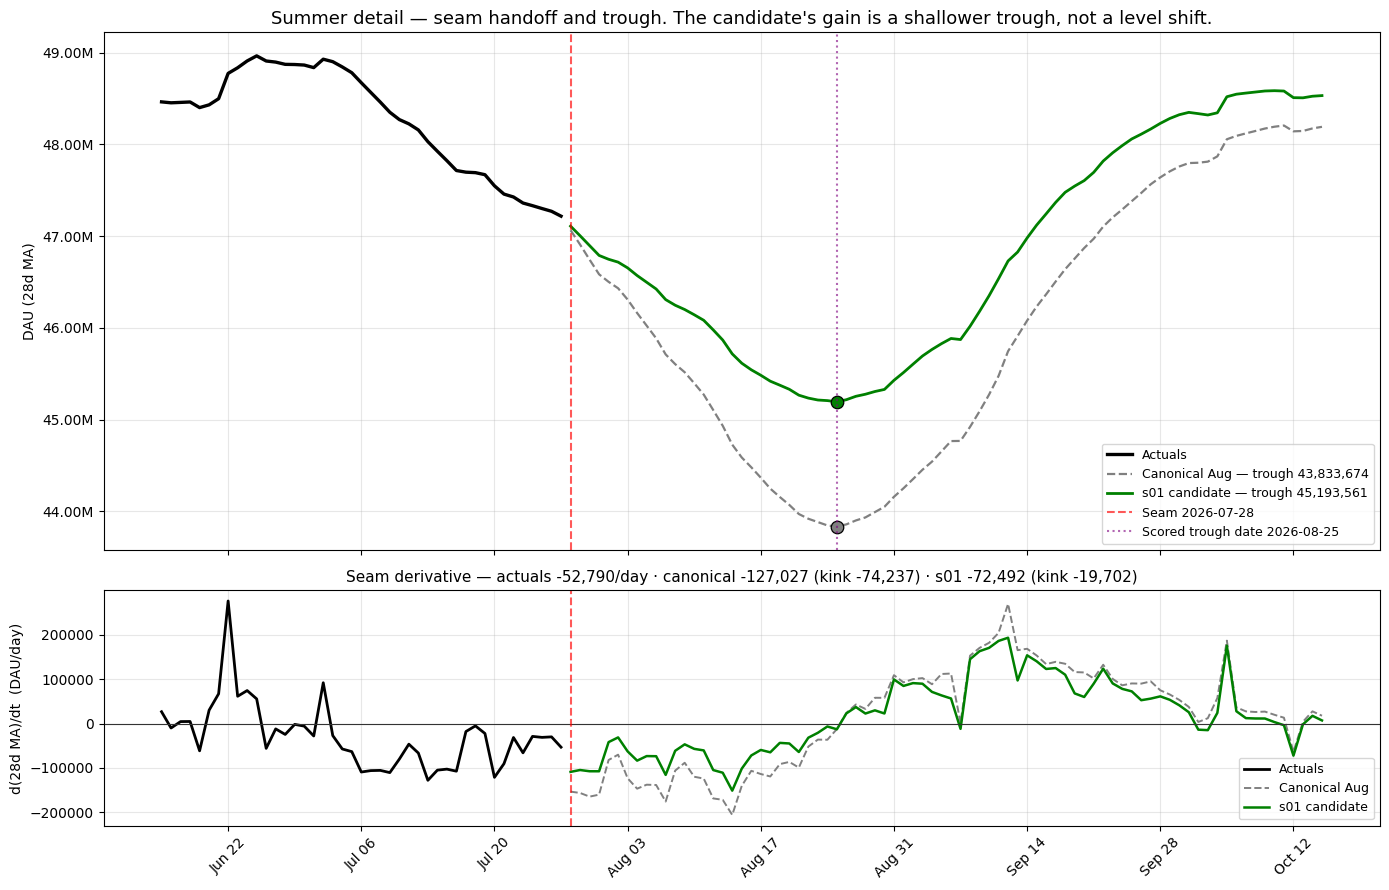

In [9]:
# [plot-summer-zoom]
# The decision-relevant view: the seam handoff and the trough itself, where the candidate and the
# canonical actually diverge. Full-year charts compress this into a few pixels.
ZOOM_START = pd.Timestamp("2026-06-15")
ZOOM_END = pd.Timestamp("2026-10-15")


def zoom(s):
    return s[(s.index >= ZOOM_START) & (s.index <= ZOOM_END)].dropna()


fig, (ax, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                              gridspec_kw={"height_ratios": [2.2, 1]})

ax.plot(zoom(actual_ma), label="Actuals", color="black", linewidth=2.4)
ax.plot(zoom(canon_ma[canon_ma.index >= FORECAST_START]),
        label=f"Canonical Aug — trough {metrics['canonical']['trough']:,.0f}",
        color="grey", linewidth=1.6, linestyle="--")
ax.plot(zoom(s01_ma[s01_ma.index >= FORECAST_START]),
        label=f"s01 candidate — trough {metrics['s01']['trough']:,.0f}",
        color="green", linewidth=2)

for name, colour in [("canonical", "grey"), ("s01", "green")]:
    m = metrics[name]
    ax.plot(m["trough_date"], m["trough"], marker="o", color=colour, markersize=9,
            markeredgecolor="black", markeredgewidth=0.9, linestyle="None")
ax.axvline(FORECAST_START, color="red", linestyle="--", alpha=0.65,
           label=f"Seam {FORECAST_START.date()}")
ax.axvline(TROUGH_DATE, color="purple", linestyle=":", alpha=0.6,
           label=f"Scored trough date {TROUGH_DATE.date()}")
ax.set_ylabel("DAU (28d MA)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.set_title("Summer detail — seam handoff and trough. The candidate's gain is a shallower "
             "trough, not a level shift.", fontsize=13)
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)

# Lower panel: day-over-day slope of the 28d-MA. This is the derivative the seam handoff is
# judged on -- a matching slope means the forecast leaves the actuals without a kink.
for label, ma, colour, lw in [("Actuals", actual_ma, "black", 2.0),
                              ("Canonical Aug", canon_ma, "grey", 1.4),
                              ("s01 candidate", s01_ma, "green", 1.8)]:
    slope = ma.diff()
    seg = zoom(slope) if label == "Actuals" else zoom(slope[slope.index >= FORECAST_START])
    ax2.plot(seg, label=label, color=colour, linewidth=lw,
             linestyle="--" if label == "Canonical Aug" else "-")
ax2.axhline(0, color="#333", linewidth=0.8)
ax2.axvline(FORECAST_START, color="red", linestyle="--", alpha=0.65)
ax2.set_ylabel("d(28d MA)/dt  (DAU/day)")
ax2.set_title(f"Seam derivative — actuals {metrics['s01']['seam_before']:+,.0f}/day · "
              f"canonical {metrics['canonical']['seam_after']:+,.0f} "
              f"(kink {metrics['canonical']['seam_kink']:+,.0f}) · "
              f"s01 {metrics['s01']['seam_after']:+,.0f} "
              f"(kink {metrics['s01']['seam_kink']:+,.0f})", fontsize=11)
ax2.legend(loc="lower right", fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
out = f"{PLOTS_DIR}/s01_desktop_summer_zoom.png"
fig.savefig(out, dpi=130)
print(f"saved: {out}")
plt.show()


saved: research/param-scans/summer-trough-v2/plots/s01_desktop_delta_vs_canonical.png


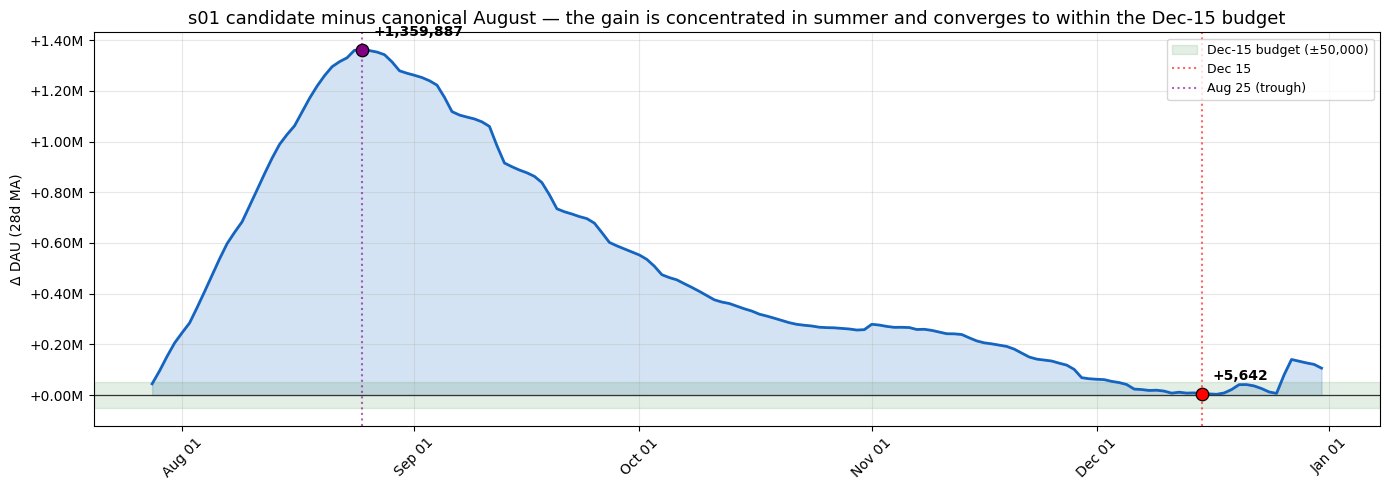


delta at seam 2026-07-28: +44,417
max delta: +1,360,379 on 2026-08-24
delta at Dec-15: +5,642


In [10]:
# [plot-delta]
# Where across the year the candidate differs from canonical. The point of this chart is that
# the gain is concentrated in summer and converges by Dec-15 -- which is the whole requirement.
delta = (s01_ma - canon_ma).loc[FORECAST_START:DISPLAY_END].dropna()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(delta, color="#1565c0", linewidth=2)
ax.fill_between(delta.index, 0, delta.values, alpha=0.18, color="#1565c0")
ax.axhline(0, color="#333", linewidth=0.9)
ax.axhspan(-DEC_TOL, DEC_TOL, color="#2e7d32", alpha=0.13,
           label=f"Dec-15 budget (±{DEC_TOL:,})")
ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.6, label="Dec 15")
ax.axvline(TROUGH_DATE, color="purple", linestyle=":", alpha=0.6, label="Aug 25 (trough)")

for date, colour in [(TROUGH_DATE, "purple"), (MEASUREMENT_DATE, "red")]:
    val = delta.loc[date]
    ax.plot(date, val, marker="o", color=colour, markersize=9, markeredgecolor="black",
            markeredgewidth=0.9, linestyle="None")
    ax.annotate(f"{val:+,.0f}", (date, val), textcoords="offset points",
                xytext=(8, 10 if val > 0 else -16), fontsize=10, fontweight="bold")

ax.set_title("s01 candidate minus canonical August — the gain is concentrated in summer and "
             "converges to within the Dec-15 budget", fontsize=13)
ax.set_ylabel("Δ DAU (28d MA)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"{v/1e6:+.2f}M"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
out = f"{PLOTS_DIR}/s01_desktop_delta_vs_canonical.png"
fig.savefig(out, dpi=130)
print(f"saved: {out}")
plt.show()

print(f"\ndelta at seam {delta.index[0].date()}: {delta.iloc[0]:+,.0f}")
print(f"max delta: {delta.max():+,.0f} on {delta.idxmax().date()}")
print(f"delta at Dec-15: {delta.loc[MEASUREMENT_DATE]:+,.0f}")
